<a href="https://colab.research.google.com/github/techasit239/Final-Project---DADS6003/blob/main/M_L_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import nltk

# โหลด tokenizer ของ NLTK
nltk.download('punkt')
nltk.download('punkt_tab')   # เพิ่มตัวนี้
nltk.download('averaged_perceptron_tagger')  # สำหรับ pos_tag ถ้าใช้

print("✅ NLTK resources loaded successfully!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...


✅ NLTK resources loaded successfully!


[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 69.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
=== RandomForest Classification Report ===
              precision    recall  f1-score   support

           0       0.86      0.60      0.71        10
           1       0.69      0.90      0.78        10

    accuracy                           0.75        20
   macro avg       0.77      0.75      0.74        20
weighted avg       0.77      0.75      0.74        20

=== XGBoost Classification Report ===
              precision    recall  f1-score   support

           0       1.00      0.70      0.82        10
           1       0.77      1.00      0.87        10

    accurac

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:55:25] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== CatBoost Classification Report ===
              precision    recall  f1-score   support

           0       0.88      0.70      0.78        10
           1       0.75      0.90      0.82        10

    accuracy                           0.80        20
   macro avg       0.81      0.80      0.80        20
weighted avg       0.81      0.80      0.80        20



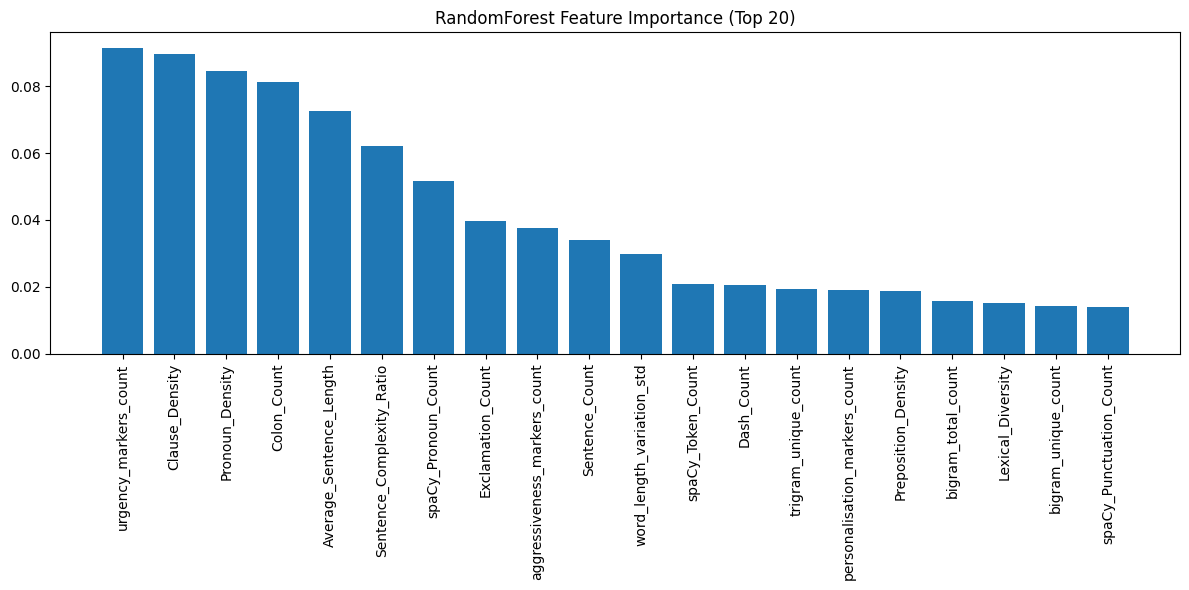

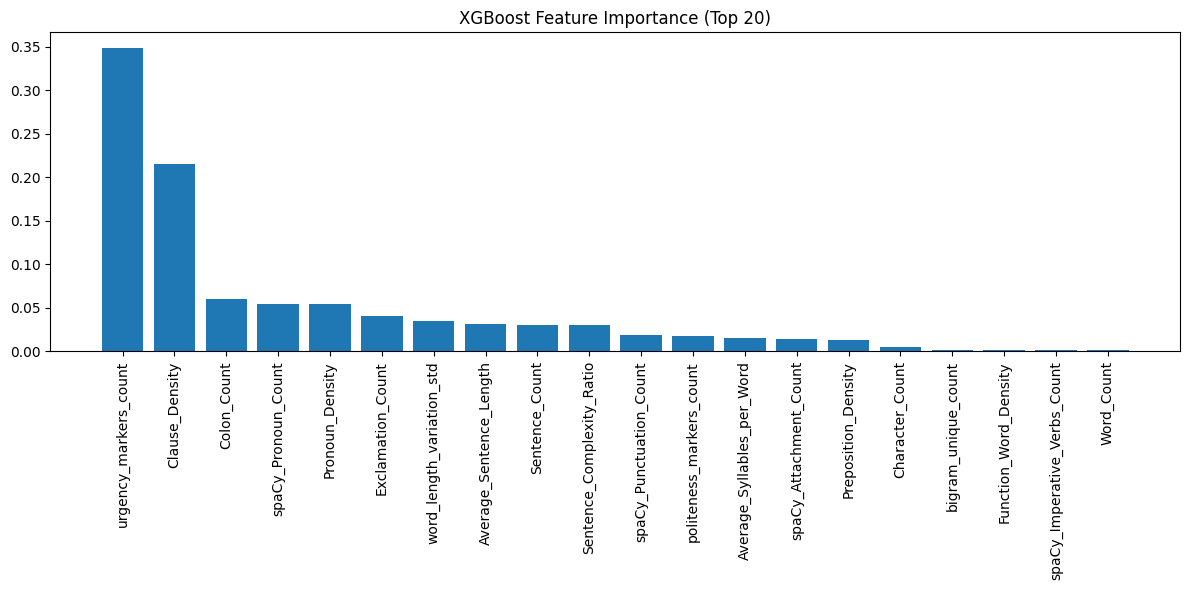

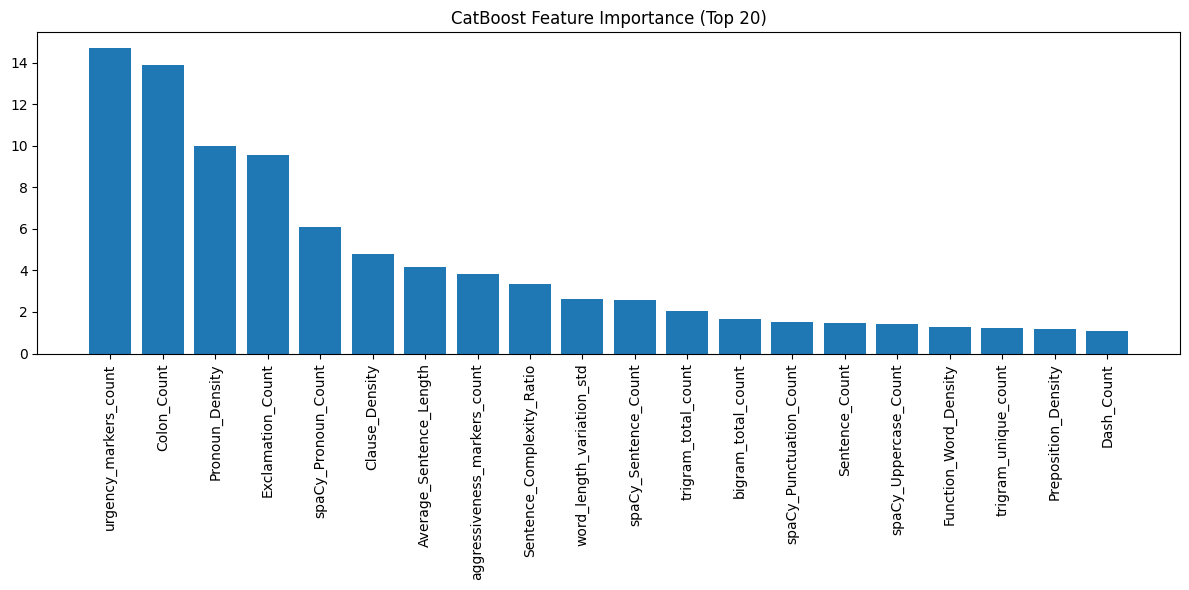

ValueError: could not convert string to float: 'An Exciting Opportunity to Engage in a Personal Relationship, David'

In [5]:
# =======================================
# 0) Install dependencies
# =======================================
!pip install -q pandas numpy spacy scikit-learn xgboost catboost matplotlib openpyxl pyarrow textstat nltk
import pandas as pd
import numpy as np
import re
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
import textstat
from nltk.tokenize import word_tokenize, sent_tokenize
from statistics import pstdev
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report

# Download spaCy model
!python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm")

# =======================================
# 1) Feature extraction functions
# =======================================
TARGET_PUNC = ['.', ',', ':', '-', '"', '(', ')', '/', '\\']
LINKING_WORDS = {'but', 'and', 'or', 'because'}
PREPOSITIONS = {'in', 'on', 'at', 'by', 'with'}
FUNCTION_WORDS = {'the', 'is', 'at', 'which', 'on', 'and', 'or', 'but', 'because'}
PERSONAL_TAGS = ["[recipient’s name]", "[Your Name]"]

def extract_main_features(text):
    words = word_tokenize(text)
    lower_words = [w.lower() for w in words if w.isalnum()]
    sentences = sent_tokenize(text)
    word_count = len(lower_words)
    char_count = len(text)
    sentence_count = len(sentences)
    avg_word_len = sum(len(w) for w in lower_words)/max(word_count,1)
    avg_sent_len = word_count / max(sentence_count,1)
    unique_word_count = len(set(lower_words))
    lexical_div = unique_word_count / max(word_count,1)
    email_count = sum(1 for w in words if '@' in w)
    upper_count = sum(1 for w in words if w.isupper() and w.isalpha())
    upper_ratio = upper_count / max(word_count,1)
    complex_count = sum(1 for w in lower_words if len(w)>6)
    total_syllables = sum(textstat.syllable_count(w) for w in lower_words)
    avg_syllables = total_syllables/max(word_count,1)
    comma_count = text.count(',')
    semicolon_count = text.count(';')
    colon_count = text.count(':')
    exclamation_count = text.count('!')
    quote_count = text.count('"')
    dash_count = text.count('-')
    linking_count = sum(1 for w in lower_words if w in LINKING_WORDS)
    sentence_complexity_ratio = linking_count/max(word_count,1)
    clause_density = linking_count/max(sentence_count,1)
    pronoun_count = sum(1 for w in lower_words if w in ['i','you','he','she','we','they'])
    pronoun_density = pronoun_count/max(word_count,1)
    preposition_count = sum(1 for w in lower_words if w in PREPOSITIONS)
    preposition_density = preposition_count/max(word_count,1)
    function_word_count = sum(1 for w in lower_words if w in FUNCTION_WORDS)
    function_word_density = function_word_count/max(word_count,1)
    return {
        'Word_Count': word_count,
        'Character_Count': char_count,
        'Average_Word_Length': avg_word_len,
        'Sentence_Count': sentence_count,
        'Average_Sentence_Length': avg_sent_len,
        'Unique_Word_Count': unique_word_count,
        'Lexical_Diversity': lexical_div,
        'Email_Count': email_count,
        'Uppercase_Word_Count': upper_count,
        'Uppercase_Word_Count_Ratio': upper_ratio,
        'Complex_Words_Count': complex_count,
        'Average_Syllables_per_Word': avg_syllables,
        'Comma_Count': comma_count,
        'Semicolon_Count': semicolon_count,
        'Colon_Count': colon_count,
        'Exclamation_Count': exclamation_count,
        'Quotation_Count': quote_count,
        'Dash_Count': dash_count,
        'Sentence_Complexity_Ratio': sentence_complexity_ratio,
        'Clause_Density': clause_density,
        'Pronoun_Density': pronoun_density,
        'Preposition_Density': preposition_density,
        'Function_Word_Density': function_word_density
    }

def extract_spacy_features(text):
    doc = nlp(text)
    tokens = [t.text for t in doc if t.is_alpha]
    num_tokens = len(tokens)
    num_sentences = len(list(doc.sents))
    punctuation_count = sum(1 for t in doc if t.is_punct)
    punctuation_variety = len(set(t.text for t in doc if t.is_punct))
    uppercase_count = sum(1 for t in tokens if t.isupper())
    uppercase_ratio = uppercase_count / max(num_tokens,1)
    pronoun_count = sum(1 for t in doc if t.pos_=='PRON')
    modal_verbs = ["can","could","may","might","must","should","would"]
    modal_count = sum(1 for t in tokens if t.lower() in modal_verbs)
    imperative_count = sum(1 for sent in doc.sents if sent[0].pos_=='VERB')
    num_emails = len(re.findall(r'\S+@\S+', text))
    attachment_terms = ["attach","attachment","file","included","enclosed"]
    attachment_count = sum(text.lower().count(term) for term in attachment_terms)
    complex_count = sum(1 for t in tokens if len(t)>6)
    return {
        'spaCy_Token_Count': num_tokens,
        'spaCy_Sentence_Count': num_sentences,
        'spaCy_Punctuation_Count': punctuation_count,
        'spaCy_Punctuation_Variety': punctuation_variety,
        'spaCy_Uppercase_Count': uppercase_count,
        'spaCy_Uppercase_Ratio': uppercase_ratio,
        'spaCy_Pronoun_Count': pronoun_count,
        'spaCy_Modal_Verbs_Count': modal_count,
        'spaCy_Imperative_Verbs_Count': imperative_count,
        'spaCy_Email_Count': num_emails,
        'spaCy_Attachment_Count': attachment_count,
        'spaCy_Complex_Words_Count': complex_count
    }

def build_all_features(df):
    df['text'] = df['Subject'].fillna('') + ' ' + df['Body'].fillna('')
    main_features = df['text'].apply(extract_main_features)
    main_df = pd.DataFrame(list(main_features))
    spacy_features = df['text'].apply(extract_spacy_features)
    spacy_df = pd.DataFrame(list(spacy_features))
    df_all = pd.concat([df.reset_index(drop=True), main_df, spacy_df], axis=1)
    return df_all

# =======================================
# 2) Load dataset
# =======================================
df = pd.read_csv("email_features.csv")  # ต้องมี Subject, Body, Label
df_all = build_all_features(df)
df_all['Label_numeric'] = df_all['Label'].map({'Legitimate':0, 'Phishing':1})

drop_cols = ['Subject','Body','Label','Label_numeric','text']
X = df_all.drop(columns=[c for c in drop_cols if c in df_all.columns])
y = df_all['Label_numeric']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =======================================
# 3) Train Models
# =======================================
# RandomForest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("=== RandomForest Classification Report ===")
print(classification_report(y_test, y_pred_rf))

# XGBoost
xgb_model = xgb.XGBClassifier(n_estimators=200, use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
print("=== XGBoost Classification Report ===")
print(classification_report(y_test, y_pred_xgb))

# CatBoost
cat_model = CatBoostClassifier(iterations=200, learning_rate=0.1, depth=6, verbose=0, random_state=42)
cat_model.fit(X_train, y_train)
y_pred_cat = cat_model.predict(X_test)
print("=== CatBoost Classification Report ===")
print(classification_report(y_test, y_pred_cat))

# =======================================
# 4) Feature Importance Plot
# =======================================
def plot_feature_importance(model, X, top_n=20, title="Feature Importance"):
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
    else:
        importances = model.get_feature_importance()
    indices = np.argsort(importances)[::-1]
    plt.figure(figsize=(12,6))
    plt.title(title)
    plt.bar(range(top_n), importances[indices[:top_n]], align='center')
    plt.xticks(range(top_n), X.columns[indices[:top_n]], rotation=90)
    plt.tight_layout()
    plt.show()

plot_feature_importance(rf, X, title="RandomForest Feature Importance (Top 20)")
plot_feature_importance(xgb_model, X, title="XGBoost Feature Importance (Top 20)")
plot_feature_importance(cat_model, X, title="CatBoost Feature Importance (Top 20)")

# =======================================
# 5) Correlation Heatmap (Top Predictive Features)
# =======================================
df_all['Label_numeric'] = df_all['Label'].map({'Legitimate':0, 'Phishing':1})
corr = df_all.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Features")
plt.show()

# =======================================
# 6) Export Features + Predictions
# =======================================
df_all['RF_Pred'] = y_pred_rf
df_all['XGB_Pred'] = y_pred_xgb
df_all['CatBoost_Pred'] = y_pred_cat

df_all.to_csv("email_features_full_with_preds.csv", index=False)
df_all.to_excel("email_features_full_with_preds.xlsx", index=False)
df_all.to_parquet("email_features_full_with_preds.parquet", index=False)
print("✅ Exported all features with predictions to CSV / Excel / Parquet")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 63.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
=== RandomForest Classification Report ===
              precision    recall  f1-score   support

           0       1.00      0.77      0.87        13
           1       0.81      1.00      0.90        13

    accuracy                           0.88        26
   macro avg       0.91      0.88      0.88        26
weighted avg       0.91      0.88      0.88        26

=== XGBoost Classification Report ===
              precision    recall  f1-score   support

           0       0.92      0.85      0.88        13
           1       0.86      0.92      0.89        13

    accurac

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:47:41] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== CatBoost Classification Report ===
              precision    recall  f1-score   support

           0       0.92      0.85      0.88        13
           1       0.86      0.92      0.89        13

    accuracy                           0.88        26
   macro avg       0.89      0.88      0.88        26
weighted avg       0.89      0.88      0.88        26



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== Logistic Regression Classification Report ===
              precision    recall  f1-score   support

           0       0.91      0.77      0.83        13
           1       0.80      0.92      0.86        13

    accuracy                           0.85        26
   macro avg       0.85      0.85      0.85        26
weighted avg       0.85      0.85      0.85        26

=== SVM Classification Report ===
              precision    recall  f1-score   support

           0       0.54      1.00      0.70        13
           1       1.00      0.15      0.27        13

    accuracy                           0.58        26
   macro avg       0.77      0.58      0.48        26
weighted avg       0.77      0.58      0.48        26

=== AdaBoost Classification Report ===
              precision    recall  f1-score   support

           0       0.91      0.77      0.83        13
           1       0.80      0.92      0.86        13

    accuracy                           0.85        26
   ma

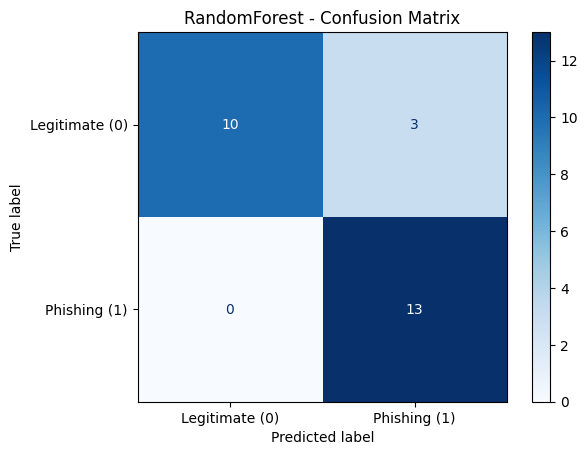

Accuracy : 0.8846
Precision: 0.8125  (Phishing = 1)
Recall   : 1.0000  (Detect phishing)
F1-Score : 0.8966
AUC      : 0.9467


========== XGBoost ==========


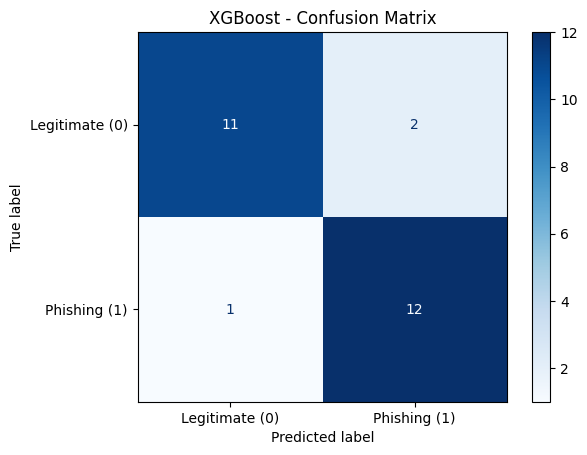

Accuracy : 0.8846
Precision: 0.8571  (Phishing = 1)
Recall   : 0.9231  (Detect phishing)
F1-Score : 0.8889
AUC      : 0.9408


========== CatBoost ==========


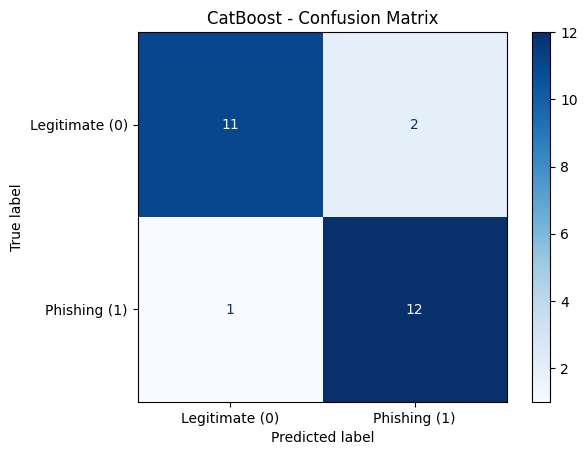

Accuracy : 0.8846
Precision: 0.8571  (Phishing = 1)
Recall   : 0.9231  (Detect phishing)
F1-Score : 0.8889
AUC      : 0.9408


========== Logistic Regression ==========


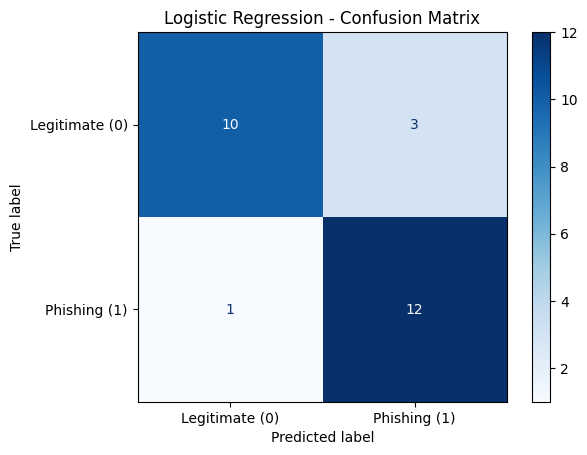

Accuracy : 0.8462
Precision: 0.8000  (Phishing = 1)
Recall   : 0.9231  (Detect phishing)
F1-Score : 0.8571
AUC      : 0.9586


========== SVM ==========


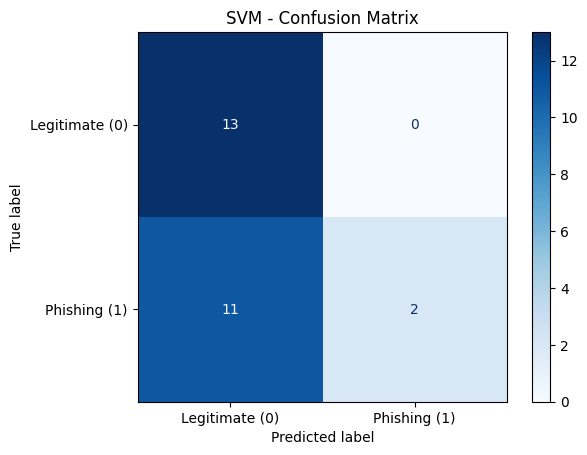

Accuracy : 0.5769
Precision: 1.0000  (Phishing = 1)
Recall   : 0.1538  (Detect phishing)
F1-Score : 0.2667
AUC      : 0.4556


========== AdaBoost ==========


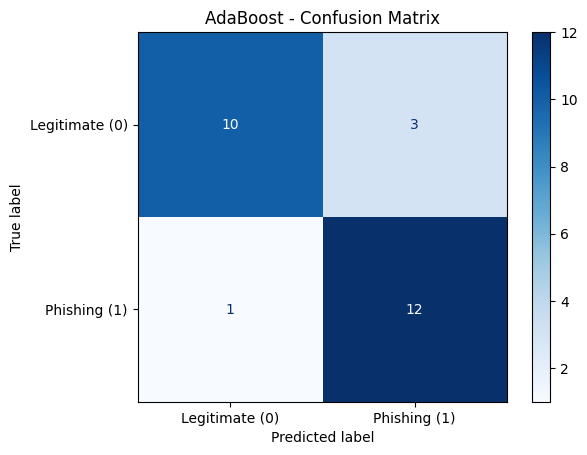

Accuracy : 0.8462
Precision: 0.8000  (Phishing = 1)
Recall   : 0.9231  (Detect phishing)
F1-Score : 0.8571
AUC      : 0.9408

===== Summary of All Model Metrics =====
                 Model  Accuracy  Precision    Recall        F1       AUC
0         RandomForest  0.884615   0.812500  1.000000  0.896552  0.946746
1              XGBoost  0.884615   0.857143  0.923077  0.888889  0.940828
2             CatBoost  0.884615   0.857143  0.923077  0.888889  0.940828
3  Logistic Regression  0.846154   0.800000  0.923077  0.857143  0.958580
4                  SVM  0.576923   1.000000  0.153846  0.266667  0.455621
5             AdaBoost  0.846154   0.800000  0.923077  0.857143  0.940828


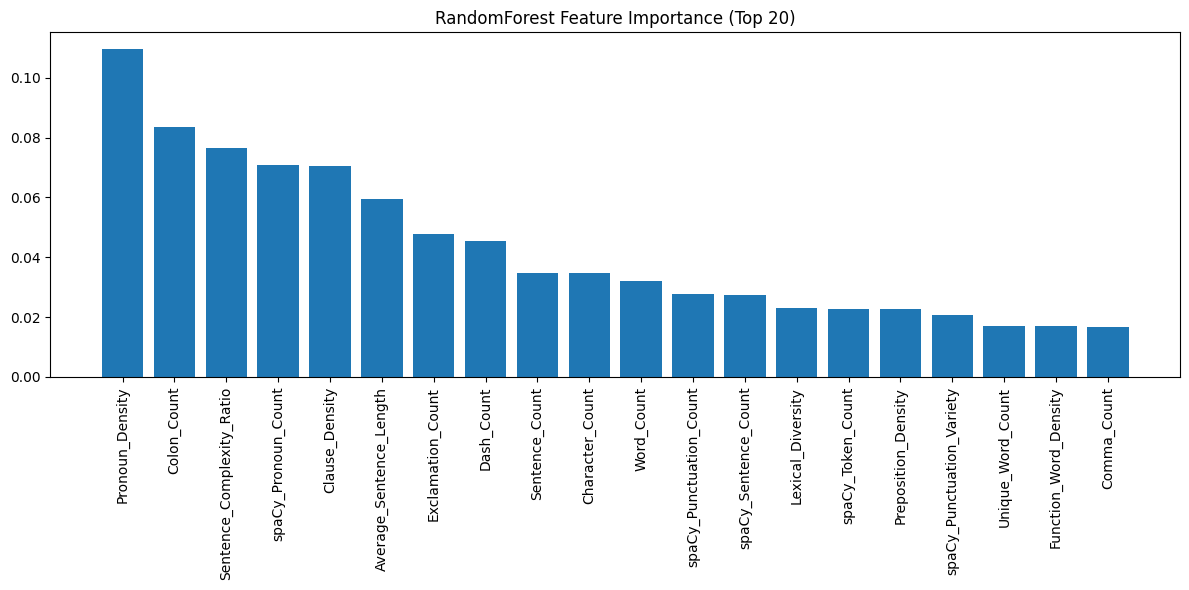

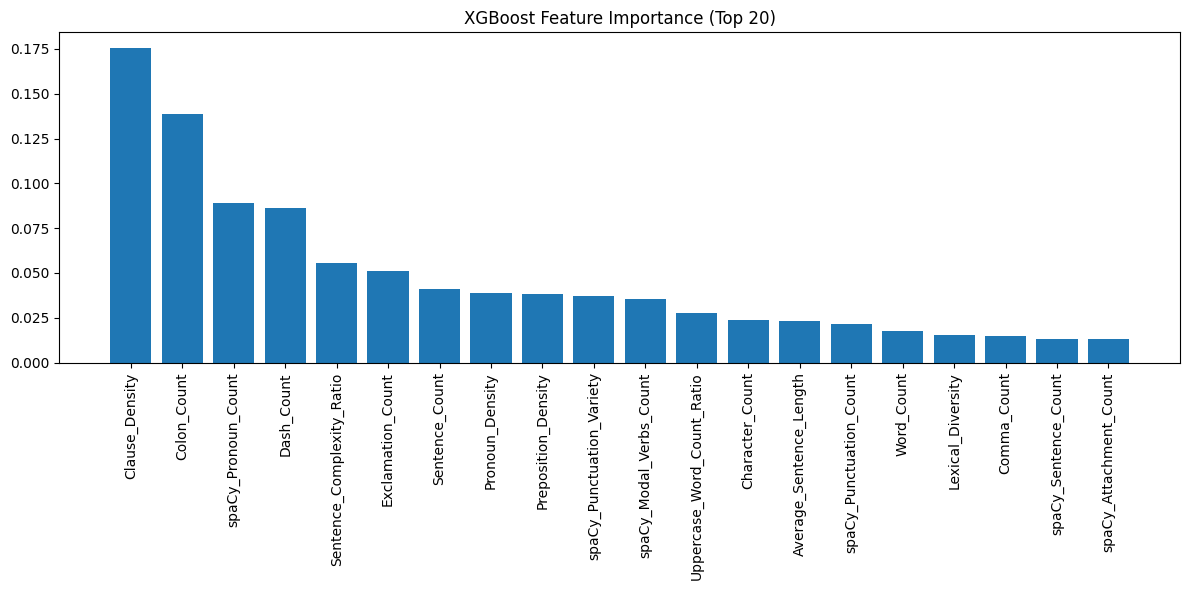

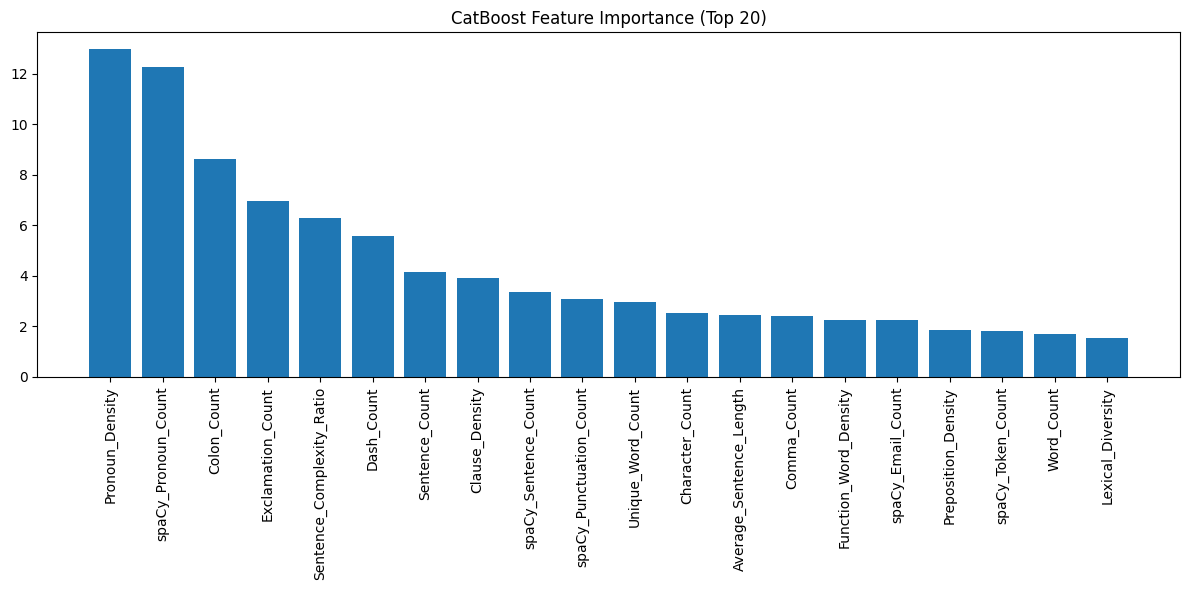

AttributeError: 'LogisticRegression' object has no attribute 'get_feature_importance'

In [12]:
# =======================================
# 0) Install & Import dependencies
# =======================================
!pip install -q pandas numpy spacy scikit-learn xgboost catboost matplotlib openpyxl pyarrow textstat nltk

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textstat

import nltk
from nltk.tokenize import word_tokenize, sent_tokenize

import spacy
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import xgboost as xgb
from catboost import CatBoostClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

# ---------------------------------------
# Download models / resources
# ---------------------------------------
nltk.download('punkt')
!python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm")


# =======================================
# 1) Feature extraction functions
# =======================================
TARGET_PUNC = ['.', ',', ':', '-', '"', '(', ')', '/', '\\']
LINKING_WORDS = {'but', 'and', 'or', 'because'}
PREPOSITIONS = {'in', 'on', 'at', 'by', 'with'}
FUNCTION_WORDS = {'the', 'is', 'at', 'which', 'on', 'and', 'or', 'but', 'because'}
PERSONAL_TAGS = ["[recipient’s name]", "[Your Name]"]  # เผื่อใช้ต่อยอดทีหลัง

def extract_main_features(text: str) -> dict:
    words = word_tokenize(text)
    lower_words = [w.lower() for w in words if w.isalnum()]
    sentences = sent_tokenize(text)

    word_count = len(lower_words)
    char_count = len(text)
    sentence_count = len(sentences)

    avg_word_len = sum(len(w) for w in lower_words) / max(word_count, 1)
    avg_sent_len = word_count / max(sentence_count, 1)

    unique_word_count = len(set(lower_words))
    lexical_div = unique_word_count / max(word_count, 1)

    email_count = sum(1 for w in words if '@' in w)
    upper_count = sum(1 for w in words if w.isupper() and w.isalpha())
    upper_ratio = upper_count / max(word_count, 1)

    complex_count = sum(1 for w in lower_words if len(w) > 6)
    total_syllables = sum(textstat.syllable_count(w) for w in lower_words)
    avg_syllables = total_syllables / max(word_count, 1)

    comma_count = text.count(',')
    semicolon_count = text.count(';')
    colon_count = text.count(':')
    exclamation_count = text.count('!')
    quote_count = text.count('"')
    dash_count = text.count('-')

    linking_count = sum(1 for w in lower_words if w in LINKING_WORDS)
    sentence_complexity_ratio = linking_count / max(word_count, 1)
    clause_density = linking_count / max(sentence_count, 1)

    pronoun_count = sum(1 for w in lower_words if w in ['i', 'you', 'he', 'she', 'we', 'they'])
    pronoun_density = pronoun_count / max(word_count, 1)

    preposition_count = sum(1 for w in lower_words if w in PREPOSITIONS)
    preposition_density = preposition_count / max(word_count, 1)

    function_word_count = sum(1 for w in lower_words if w in FUNCTION_WORDS)
    function_word_density = function_word_count / max(word_count, 1)

    return {
        'Word_Count': word_count,
        'Character_Count': char_count,
        'Average_Word_Length': avg_word_len,
        'Sentence_Count': sentence_count,
        'Average_Sentence_Length': avg_sent_len,
        'Unique_Word_Count': unique_word_count,
        'Lexical_Diversity': lexical_div,
        'Email_Count': email_count,
        'Uppercase_Word_Count': upper_count,
        'Uppercase_Word_Count_Ratio': upper_ratio,
        'Complex_Words_Count': complex_count,
        'Average_Syllables_per_Word': avg_syllables,
        'Comma_Count': comma_count,
        'Semicolon_Count': semicolon_count,
        'Colon_Count': colon_count,
        'Exclamation_Count': exclamation_count,
        'Quotation_Count': quote_count,
        'Dash_Count': dash_count,
        'Sentence_Complexity_Ratio': sentence_complexity_ratio,
        'Clause_Density': clause_density,
        'Pronoun_Density': pronoun_density,
        'Preposition_Density': preposition_density,
        'Function_Word_Density': function_word_density,
    }


def extract_spacy_features(text: str) -> dict:
    doc = nlp(text)

    tokens = [t.text for t in doc if t.is_alpha]
    num_tokens = len(tokens)
    num_sentences = len(list(doc.sents))

    punctuation_count = sum(1 for t in doc if t.is_punct)
    punctuation_variety = len(set(t.text for t in doc if t.is_punct))

    uppercase_count = sum(1 for t in tokens if t.isupper())
    uppercase_ratio = uppercase_count / max(num_tokens, 1)

    pronoun_count = sum(1 for t in doc if t.pos_ == 'PRON')

    modal_verbs = {"can", "could", "may", "might", "must", "should", "would"}
    modal_count = sum(1 for t in tokens if t.lower() in modal_verbs)

    # นับประโยคที่ขึ้นต้นด้วย VERB (approx imperative)
    imperative_count = sum(1 for sent in doc.sents if len(sent) > 0 and sent[0].pos_ == 'VERB')

    num_emails = len(re.findall(r'\S+@\S+', text))

    attachment_terms = ["attach", "attachment", "file", "included", "enclosed"]
    attachment_count = sum(text.lower().count(term) for term in attachment_terms)

    complex_count = sum(1 for t in tokens if len(t) > 6)

    return {
        'spaCy_Token_Count': num_tokens,
        'spaCy_Sentence_Count': num_sentences,
        'spaCy_Punctuation_Count': punctuation_count,
        'spaCy_Punctuation_Variety': punctuation_variety,
        'spaCy_Uppercase_Count': uppercase_count,
        'spaCy_Uppercase_Ratio': uppercase_ratio,
        'spaCy_Pronoun_Count': pronoun_count,
        'spaCy_Modal_Verbs_Count': modal_count,
        'spaCy_Imperative_Verbs_Count': imperative_count,
        'spaCy_Email_Count': num_emails,
        'spaCy_Attachment_Count': attachment_count,
        'spaCy_Complex_Words_Count': complex_count,
    }


def build_all_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['text'] = df['Subject'].fillna('') + ' ' + df['Body'].fillna('')

    main_features = df['text'].apply(extract_main_features)
    main_df = pd.DataFrame(list(main_features))

    spacy_features = df['text'].apply(extract_spacy_features)
    spacy_df = pd.DataFrame(list(spacy_features))

    df_all = pd.concat([df.reset_index(drop=True), main_df, spacy_df], axis=1)
    return df_all


# =======================================
# 2) Load dataset & build features
# =======================================

'''
if __name__ == "__main__":

    # 1. โหลดข้อมูล
    df = load_email_excel(INPUT_PATH) if IS_EXCEL else load_email_csv(INPUT_PATH)

    # 2. สร้างฟีเจอร์จาก Subject + Body
    feature_df = build_feature_dataframe(df)

    # 3. เตรียม X และ y ตามที่โค้ดเดิมตั้งใจไว้
    # เลือกเฉพาะฟีเจอร์เป็น X
    feature_cols = [col for col in feature_df.columns
                    if col not in ["Subject", "Body", "Label"]]

    X = feature_df[feature_cols]
    y = feature_df["Label"]

    # 4. บันทึก Feature DataFrame ที่รวมแล้ว (ตามส่วน MAIN เดิมที่ถูกคอมเมนต์ไว้)
    out = feature_df.copy()
    out.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")
'''


# ต้องมีคอลัมน์: Subject, Body, Label (Legitimate / Phishing)
df = pd.read_csv("email_features.csv")

df_all = build_all_features(df)
df_all['Label_numeric'] = df_all['Label'].map({'Legitimate': 0, 'Phishing': 1})

# เลือกเฉพาะ feature columns (ตัด text ดิบออก)
drop_cols = ['Subject', 'Body', 'Label', 'Label_numeric', 'text']
X = df_all.drop(columns=[c for c in drop_cols if c in df_all.columns])

# กันเหนียว: เอาเฉพาะคอลัมน์ตัวเลข (เผื่อมี column object แทรกมา)
X = X.select_dtypes(include=[np.number])

y = df_all['Label_numeric']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 🔧 แก้ issue xgboost + pandas: แปลงเป็น numpy
X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()


# =======================================
# 3) Train Models
# =======================================
# RandomForest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_np, y_train_np)
y_pred_rf = rf.predict(X_test_np)
print("=== RandomForest Classification Report ===")
print(classification_report(y_test_np, y_pred_rf))

# XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train_np, y_train_np)
y_pred_xgb = xgb_model.predict(X_test_np)
print("=== XGBoost Classification Report ===")
print(classification_report(y_test_np, y_pred_xgb))

# CatBoost
cat_model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    verbose=0,
    random_state=42
)
cat_model.fit(X_train_np, y_train_np)
y_pred_cat = cat_model.predict(X_test_np)
# cat_model.predict คืนมาเป็น shape (n_samples,1) บางเวอร์ชัน → แปลงเป็น 1D
y_pred_cat = y_pred_cat.ravel().astype(int)
print("=== CatBoost Classification Report ===")
print(classification_report(y_test_np, y_pred_cat))

# Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    random_state=42
)
lr_model.fit(X_train_np, y_train_np)
y_pred_lr = lr_model.predict(X_test_np)
print("=== Logistic Regression Classification Report ===")
print(classification_report(y_test_np, y_pred_lr))

# SVM (มี probability=True เพื่อใช้คำนวณ AUC)
svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)
svm_model.fit(X_train_np, y_train_np)
y_pred_svm = svm_model.predict(X_test_np)
print("=== SVM Classification Report ===")
print(classification_report(y_test_np, y_pred_svm))

# AdaBoost
ada_model = AdaBoostClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)
ada_model.fit(X_train_np, y_train_np)
y_pred_ada = ada_model.predict(X_test_np)
print("=== AdaBoost Classification Report ===")
print(classification_report(y_test_np, y_pred_ada))



# =======================================
# 3.1) Confusion Matrix + Metrics (Acc/Prec/Rec/F1/AUC)
# =======================================
def evaluate_model(y_true, y_pred, y_proba, model_name: str) -> dict:
    print(f"\n\n========== {model_name} ==========")

    # Confusion Matrix (0 = Legitimate, 1 = Phishing)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Legitimate (0)", "Phishing (1)"]
    )
    disp.plot(values_format='d', cmap='Blues')
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    # Metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, pos_label=1)
    recall = recall_score(y_true, y_pred, pos_label=1)
    f1 = f1_score(y_true, y_pred, pos_label=1)
    auc = roc_auc_score(y_true, y_proba)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}  (Phishing = 1)")
    print(f"Recall   : {recall:.4f}  (Detect phishing)")
    print(f"F1-Score : {f1:.4f}")
    print(f"AUC      : {auc:.4f}")

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc,
    }

# Probabilities for AUC (ใช้ X_test_np)
rf_proba  = rf.predict_proba(X_test_np)[:, 1]
xgb_proba = xgb_model.predict_proba(X_test_np)[:, 1]
cat_proba = cat_model.predict_proba(X_test_np)[:, 1].astype(float)
lr_proba  = lr_model.predict_proba(X_test_np)[:, 1]
svm_proba = svm_model.predict_proba(X_test_np)[:, 1]
ada_proba = ada_model.predict_proba(X_test_np)[:, 1]

metrics_results = []
metrics_results.append(evaluate_model(y_test_np, y_pred_rf,  rf_proba,  "RandomForest"))
metrics_results.append(evaluate_model(y_test_np, y_pred_xgb, xgb_proba, "XGBoost"))
metrics_results.append(evaluate_model(y_test_np, y_pred_cat, cat_proba, "CatBoost"))
metrics_results.append(evaluate_model(y_test_np, y_pred_lr,  lr_proba,  "Logistic Regression"))
metrics_results.append(evaluate_model(y_test_np, y_pred_svm, svm_proba, "SVM"))
metrics_results.append(evaluate_model(y_test_np, y_pred_ada, ada_proba, "AdaBoost"))

df_metrics = pd.DataFrame(metrics_results)
print("\n===== Summary of All Model Metrics =====")
print(df_metrics)
df_metrics.to_excel("model_metrics_summary.xlsx", index=False)


# =======================================
# 4) Feature Importance Plot
# =======================================
def plot_feature_importance(model, X_df, top_n: int = 20, title: str = "Feature Importance"):
    # RandomForest / XGBoost: feature_importances_
    # CatBoost: get_feature_importance()
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
    else:
        importances = model.get_feature_importance()

    indices = np.argsort(importances)[::-1][:top_n]

    plt.figure(figsize=(12, 6))
    plt.title(title)
    plt.bar(range(len(indices)), importances[indices], align='center')
    plt.xticks(range(len(indices)), X_df.columns[indices], rotation=90)
    plt.tight_layout()
    plt.show()

plot_feature_importance(rf, X, title="RandomForest Feature Importance (Top 20)")
plot_feature_importance(xgb_model, X, title="XGBoost Feature Importance (Top 20)")
plot_feature_importance(cat_model, X, title="CatBoost Feature Importance (Top 20)")
plot_feature_importance(lr_model, X, title="Logistic Regression Feature Importance (Top 20)")
plot_feature_importance(svm_model, X, title="SVM Feature Importance (Top 20)")
plot_feature_importance(ada_model, X, title="AdaBoost Feature Importance (Top 20)")


# =======================================
# 5) Correlation Heatmap (Features + Label)
# =======================================
corr_cols = X.columns.tolist() + ['Label_numeric']
corr_df = df_all[corr_cols].copy()

corr = corr_df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Features with Label")
plt.show()


# =======================================
# 6) Export Features + Predictions
# =======================================
# ตอน export ใช้ X.values เพื่อให้เข้ากับ model ที่ train จาก numpy
X_full_np = X.to_numpy()

df_all['RF_Pred']   = rf.predict(X_full_np)
df_all['XGB_Pred']  = xgb_model.predict(X_full_np)
df_all['CatBoost_Pred'] = cat_model.predict(X_full_np).ravel().astype(int)
df_all['LR_Pred']   = lr_model.predict(X_full_np)
df_all['SVM_Pred']  = svm_model.predict(X_full_np)
df_all['ADA_Pred']  = ada_model.predict(X_full_np)


df_all.to_csv("email_features_full_with_preds.csv", index=False)
df_all.to_excel("email_features_full_with_preds.xlsx", index=False)
df_all.to_parquet("email_features_full_with_preds.parquet", index=False)

print("✅ Exported all features with predictions + metrics summary")
